# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 1. Часть 2: полносвязные нейронные сети. 

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 8.5, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 5.22 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этой части мы будем использовать фреймворк для обучения нейронный сетей, который вы реализовали в первой половине задания. А именно, вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html). Если по какой-то причине вы не сделали первую половину домашки, то **можете поставить все эксперименты на PyTorch**, но рекомендуется использовать ваши реализации модулей. 

In [1]:
import modules as mm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import clear_output

plt.rcParams.update({'font.size': 16})
sns.set_style('whitegrid')
np.random.seed(0xFA1AFE1)

Начнем с того, что скачаем и загрузим данные:

In [2]:
!wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2025-11-16 01:44:30--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: 'data.txt.zip'

     0K .......... .......... .......... .......... ..........  141K
    50K .......... .......... .......... .......... ..........  288K
   100K .......... .......... .......... .......... .......... 4,47M
   150K .......... .......... .......... .......... .......... 4,40M
   200K .......... .......... .......... .......... ..........  289K
   250K .......... .......... .......... .......... .......... 11,4M
   300K .......... .......... .......... .......... ..........  333K
   350K .......... .......... .......... .......... .......... 1,25M
   400K .......... .......... .......... .......... .......... 5,33M
   450K ..

In [3]:
df = pd.read_csv('data.txt.zip', header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515340,2006,51.28467,45.88068,22.19582,-5.53319,-3.61835,-16.36914,2.12652,5.18160,-8.66890,...,4.81440,-3.75991,-30.92584,26.33968,-5.03390,21.86037,-142.29410,3.42901,-41.14721,-15.46052
515341,2006,49.87870,37.93125,18.65987,-3.63581,-27.75665,-18.52988,7.76108,3.56109,-2.50351,...,32.38589,-32.75535,-61.05473,56.65182,15.29965,95.88193,-10.63242,12.96552,92.11633,10.88815
515342,2006,45.12852,12.65758,-38.72018,8.80882,-29.29985,-2.28706,-18.40424,-22.28726,-4.52429,...,-18.73598,-71.15954,-123.98443,121.26989,10.89629,34.62409,-248.61020,-6.07171,53.96319,-8.09364
515343,2006,44.16614,32.38368,-3.34971,-2.49165,-19.59278,-18.67098,8.78428,4.02039,-12.01230,...,67.16763,282.77624,-4.63677,144.00125,21.62652,-29.72432,71.47198,20.32240,14.83107,39.74909


Посмотрим на статистики по данным.

In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

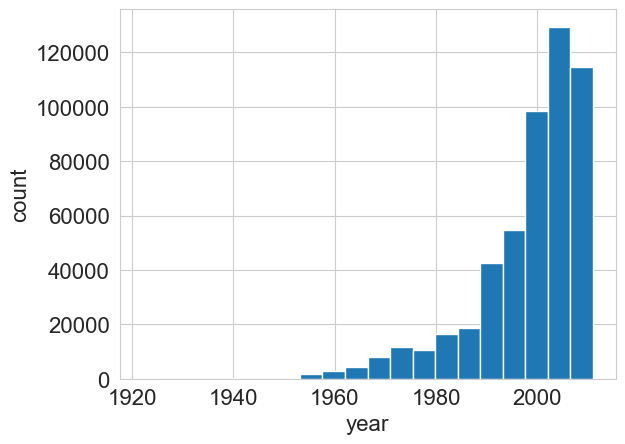

Range: 1922 - 2011
Unique values: 89


In [5]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [19]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train.shape, X_test.shape

((386508, 90), (128837, 90))

**Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов).** Мы будем использовать MSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Сначала обучим Ридж-регрессию:

In [20]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

y_pred_test = ridge_model.predict(X_test)

mse_loss_ridge = mean_squared_error(y_test, y_pred_test)
print(mse_loss_ridge)
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

89.74966397222074


Теперь посмотрим на ошибку для наилучшей константной модели

In [21]:
y_pred_for_test = np.full(y_test.shape, np.mean(y_train))
mse_loss_naive = mean_squared_error(y_test, y_pred_for_test)
print(mse_loss_naive)

117.62580230734426


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию:

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Глава I. Заводим нейронную сеть (5 баллов)

**Задание 1.1 (0.5 баллов).** Заполните пропуски в функции `train_and_validate`. Она поможет нам запускать эксперименты.

In [23]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label='train')
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label='val')

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale('log')

    if max(train_metrics) / min(train_metrics) > 10:
        axs[0].set_yscale('log')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    axs[0].set_ylabel('loss')
    axs[1].set_ylabel('MSE')
    plt.show()


def train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True):
    """
    Train and validate neural network
      - model: neural network (mm.Module) to train
      - optimizer: optimizer (mm.Optimizer) chained to a model
      - criterion: loss function class (mm.Criterion)
      - metrics: function to measure MSE taking neural networks predictions
                 and ground truth tick_labels
      - train_loader: mm.DataLoader with train set
      - val_loader: mm.DataLoader with validation set
      - num_epochs: number of epochs to train
      - verbose: whether to plot metrics during training
    Returns:
      - train_mse: training MSE over the last epoch
      - val_mse: validation MSE after the last epoch
    """
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = tqdm(train_loader, desc=f'Training {epoch}/{num_epochs}') \
            if verbose else train_loader

        for X_batch, y_batch in pbar:
            '''
            YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
            Do forward and backward passes
            predictions = ...
            loss = ...
            '''
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            model.backward(X_batch, criterion.backward(predictions, y_batch))
            optimizer.step()
            
            metric_value = metric(predictions, y_batch)
            running_loss += loss * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                pbar.set_postfix({'loss': loss, 'MSE': metric_value})

        train_losses += [running_loss / train_loader.num_samples()]
        train_metrics += [running_metric / train_loader.num_samples()]

        model.eval()
        running_loss, running_metric = 0, 0
        pbar = tqdm(val_loader, desc=f'Validating {epoch}/{num_epochs}') \
            if verbose else val_loader

        for X_batch, y_batch in pbar:
            '''
            YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
            Do evaluation
            predictions = ...
            loss = ...
            '''
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            metric_value = metric(predictions, y_batch)
            running_loss += loss * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                pbar.set_postfix({'loss': loss, 'MSE': metric_value})

        val_losses += [running_loss / val_loader.num_samples()]
        val_metrics += [running_metric / val_loader.num_samples()]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    
    if verbose:
        print(f'Validation MSE: {val_metrics[-1]:.3f}')
    
    return train_metrics[-1], val_metrics[-1]

**Задание 1.2 (0.75 балла).** Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве параметра `metric` в `train_and_validate` передайте lambda-выражение, которое считает MSE по выходу нейронной сети и целевой переменной. В случае классификации предсказывается класс с наибольшей вероятностью (или, что то же самое, с наибольшим значением логита).

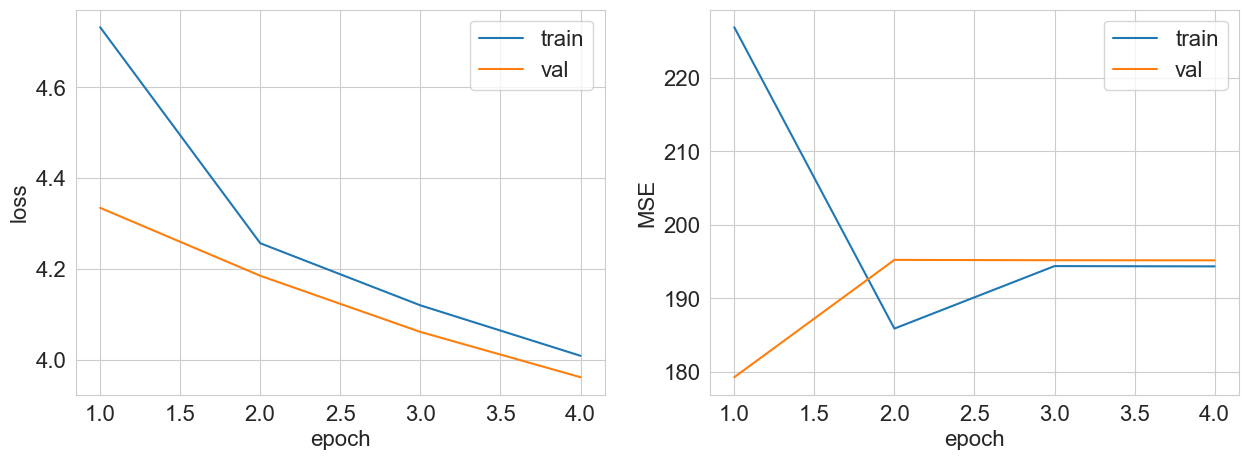

Validation MSE: 195.163


(194.34041554982906, 195.1630600142817)

In [25]:
np.random.seed(42)
model_0 = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, int(np.unique(df.iloc[:, 0]).size)),
)
    
optimizer = mm.SGD(model_0, lr=1e-3)

criterion = mm.CrossEntropyLoss()

num_epochs = 4

dict_classes = {value: clas for clas, value in enumerate(np.unique(df.iloc[:, 0]))}
y_train_scaled = np.array([dict_classes[value] for value in y_train])
y_val_scaled = np.array([dict_classes[value] for value in y_val])

train_loader = mm.DataLoader(X_train, y_train_scaled, batch_size=50, shuffle=True)
val_loader = mm.DataLoader(X_val, y_val_scaled, batch_size=50, shuffle=False)

metric = lambda x, y: mean_squared_error(y, np.argmax(x,axis=1))

train_and_validate(model_0, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True)
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

Теперь проверим качество нашей построенной модели на тесте

In [28]:
test_predicts = np.argmax(model_0(X_test), axis=1)
dict_classes = {clas: value for clas, value in enumerate(np.unique(df.iloc[:, 0]))}
y_test_predicts_unscaled = np.array([dict_classes[coded_year] for coded_year in test_predicts])
print(mean_squared_error(y_test, y_test_predicts_unscaled))

190.5706280028253


**Задание 1.3 (0.5 балла).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** Как мы можем заметить, ошибка по MSE получилась даже больше, чем у константной модели. Проблема в том, что наша модель не учитывает близость годов. Т.е. CrossEntropyLoss будет примерно одинаково оценивать ошибку в случае если мы ошибаемся с классом(независимо от того, указали мы 1990 вместо 2016 или 2015 вместо 2016), а из-за этого модель будет обучаться непредсказуемо, ведь по сути модель никогда не будет понимать насколько близко находятся друг к другу года, и даже если у них похожи признаки, то из-за большой ошибки модель может пойти в неправильную сторону. Модель может начинать просто "заучивать" закономерности и на тесте очень сильно ошибаться. При этом, в случае константной модели эта разница учитывается и поскольку в среднем значения годов выпуска песен примерно равны этому предсказанию, ошибка получается меньше. Поэтому для этой задачи учить классификатор плохая идея. На регрессии, полагаю, мы увидим намного более хорошие значения по MSE. Ну и еще можно добавить, что вообще когда мы создаем дискретные классы, то есть оставляем у модели только дискретные выходы, то не учитываем, что при истинном значении 2016 2015,5 тоже может быть хорошим предсказанием. 

**Задание 1.4 (0.75 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Не забудьте изменить lambda-выражение, которые вы передаете в `train_and_validate`.
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

В данном коде я решил проверить, насколько сойдется MSE, если сделать 10 эпох - но тоже не получил ничего хорошего, можете посмотреть

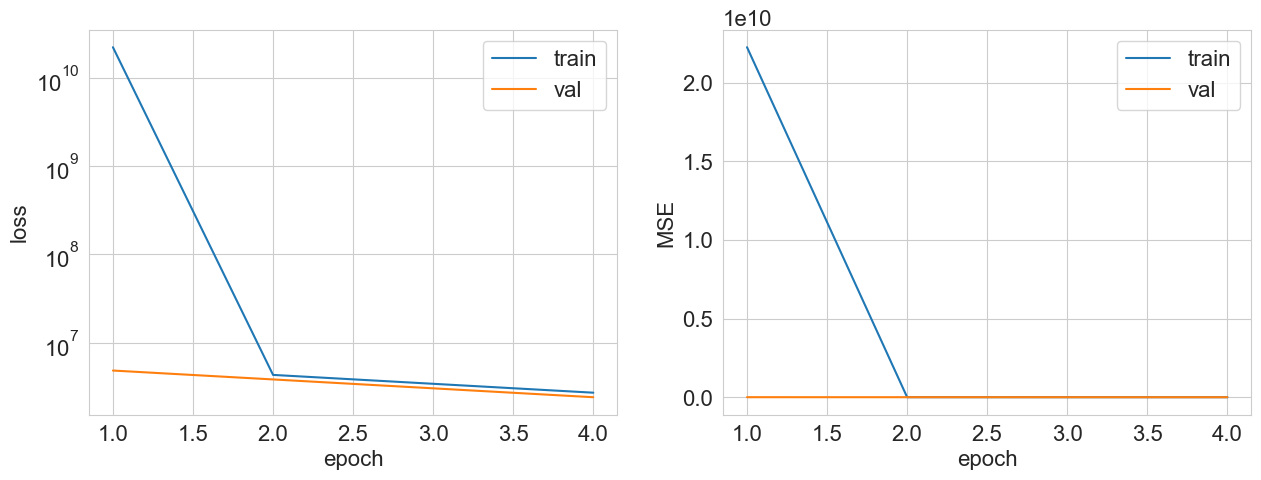

Validation MSE: 2417192.531


(2720508.8579469696, 2417192.5307236086)

In [76]:
np.random.seed(42)
model_1 = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
)
    
optimizer = mm.SGD(model_1, lr=1e-5)

criterion = mm.MSELoss()

num_epochs = 4

train_loader = mm.DataLoader(X_train, y_train.reshape(-1, 1), batch_size=50, shuffle=True)
val_loader = mm.DataLoader(X_val, y_val.reshape(-1, 1), batch_size=50, shuffle=False)

metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())

train_and_validate(model_1, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True)
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

In [41]:
test_predicts_1 = model_1(X_test)
print(mean_squared_error(y_test, test_predicts_1))

2417440.305451149


**Задание 1.5 (0.5 балла).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** Ну, по сути обучение удалось стабилизировать лишь при достаточно низких значениях параметра lr, поскольку ошибка оказывалась иначе слишком огромной и градиенты тоже, а потому делались большие шаги и модель постоянно перескакивала минимум. То есть, и вправду, при lr=1e^-3 модель вообще не смогла обучаться из-за слишком больших значений градиентов. Как только lr уменьшился до 1e^-5, сразу все начало обучаться, хоть и ошибки MSE остались все равно огромными. Пока что от замены лучше не стало, потому что года, несмотря на то, что имеют большие значения, разбросаны очень несильно (стандартное отклонение около 11), однако многие признаки имеют намного большие значения стандартного отклонения из-за чего, но большее стандартное отклонение из-за чего возникает две проблемы: во-первых, модель при обучении будет больше смотреть на признаки с большим стандартным отклонением (потому что MSE очень чувствителен к выбросом и подстраивает веса именно по ним), несмотря на то, что в модели могут быть более важные и стабильные признаки. Во-вторых, градиенты у признаков с большим разбросом будут большими, а с маленьким - маленькие, в результате чего сложно подобрать единый lr, чтобы не взорваться, но и не затухнуть. То есть по сути, так как признаки имеют большой разброс, а годы маленький, то даже для близких годов у нас будут скорее всего сильно разные значения признаков, из-за чего модели будет сложно понять закономерности и подобрать веса правильно для того, чтобы сойтись к минимуму

**Задание 1.6 (0.75 балла).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [42]:
def normalize(sample, min_y, max_y):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
    return (sample - min_y) / (max_y - min_y)

def denormalize(sample, min_y, max_y):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (max_y - min_y) + min_y

Теперь повторите эксперимент из **задания 1.4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений. 

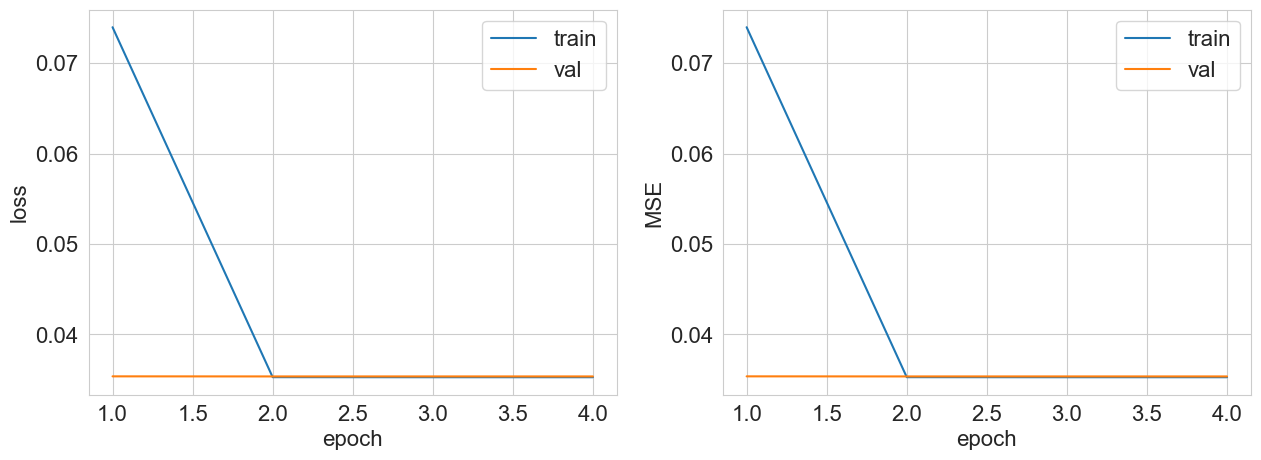

Validation MSE: 0.035


(0.03527028088519981, 0.03535744780116941)

In [43]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
np.random.seed(42)
model_2 = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid()
)
    
optimizer = mm.SGD(model_2, lr=1e-3)

criterion = mm.MSELoss()

num_epochs = 4

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

train_loader = mm.DataLoader(X_train, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
val_loader = mm.DataLoader(X_val, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)

metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())

train_and_validate(model_2, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True)
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

In [44]:
test_predicts_2 = model_2(X_test)
test_predict_2_denorm = denormalize(test_predicts_2, min_y, max_y)
print(mean_squared_error(y_test, test_predict_2_denorm))

274.8982428697742


**Задание 1.7 (0.5 балла).** Сравните результаты этого эксперимента с предыдущим запуском. 

**Ответ:** Теперь модель обучается намного лучше, чем в случае без нормировки целевых переменных, потому что теперь градиенты по выходу последнего слоя затухают (vanishing gradients) при экстремально больших и экстремально маленьких значениях (так получается, поскольку производная от сигмоиды это sigmoid(x) * (1 - sigmoid(x), которая приблизительно ноль при x -> в любую бесконечность). И поскольку этот градиент перемножается с градиентами следующих слоев (через там матричное умножение), то он тоже не дает градиентам сильно разрастаться. Поэтому решается проблема перескакивания минимума и теперь модель практически одинаково будет учитывать каждый признак и более хорошо, не метаясь, сходиться к минимуму. Тем не менее, есть и обратная сторона медали - что до минимума мы вообще можем не дойти, потому что для больших выходов градиенты уж очень сильно затухают, поэтому лучше использовать ненулевое значение momentum в SGD и накапливать градиенты

**Задание 1.8 (0.75 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

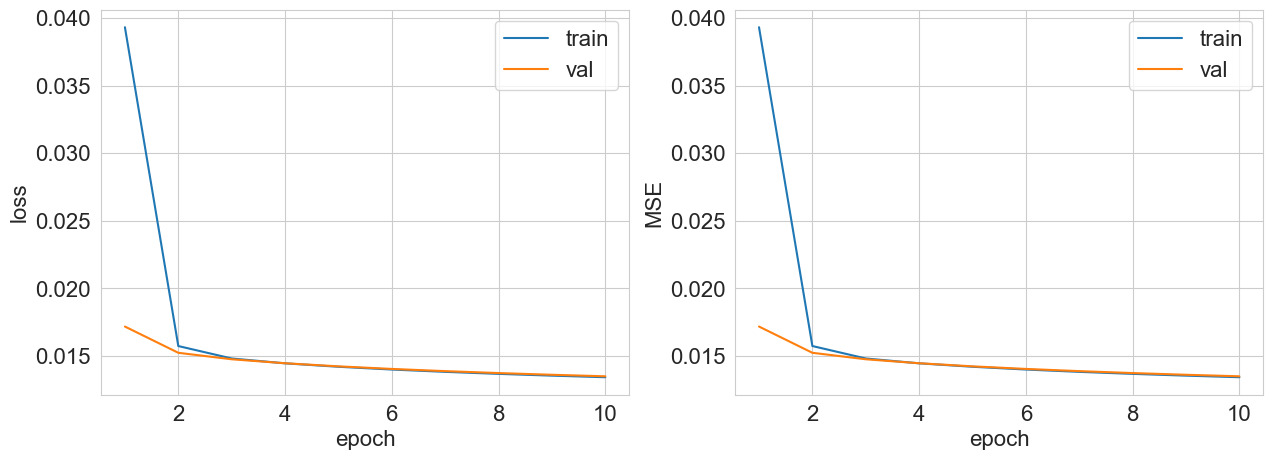

Validation MSE: 0.013


(0.013423335659818684, 0.013491554412061953)

In [46]:
from sklearn.preprocessing import StandardScaler
np.random.seed(42)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
model_3 = mm.Sequential(
    mm.Linear(X_train.shape[1], 128),
    mm.ReLU(),
    mm.Linear(128, 1),
    mm.Sigmoid()
)
    
optimizer = mm.SGD(model_3, lr=1e-3)

criterion = mm.MSELoss()

num_epochs = 10

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)

metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())

train_and_validate(model_3, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True)
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

In [95]:
test_predicts_3 = model_3(scaler.transform(X_test))
test_predicts_3_denorm = denormalize(test_predicts_3, min_y, max_y)
print(f'MSE on test: {mean_squared_error(y_test, test_predicts_3_denorm)}')

MSE on test: 103.70643720218023


Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть 2. Улучшаем нейронную сеть

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества. В заданиях 2.1-2.3 **запускайте эксперименты несколько раз (4-5)** с одинаковыми значениями гиперпараметров обучения, но с разными случайными инициализациями сети (достаточно просто прогнать код с инициализацией модели и ее обучением в цикле: каждый вызов конструктора инициализирует модель случайно). Для сравнения качества разных экспериментов **отрисовывайте ящики с усами (boxplot)** по этим нескольким запускам.

Задание 2.4 требует перебора гиперпараметров, в нем запускайте эксперимент по одному разу для каждого рассмотренного значения, чтобы сэкономить время.

**Задание 2.1 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

Для начала посмотрим на наши модели с применением SGD + Momentum

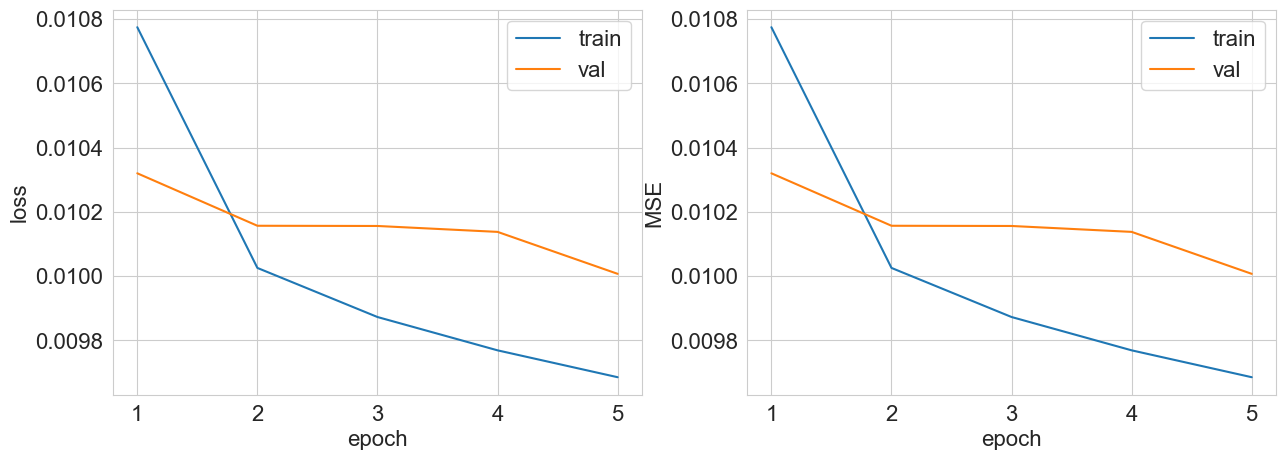

Validation MSE: 0.010


In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 5

list_metrics_SGD_M=[]

for i in range(5):
    
    np.random.seed(42 + i)
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.ReLU(),
        mm.Linear(128, 1),
        mm.Sigmoid()
    )
        
    optimizer = mm.SGD(model, lr=1e-1, momentum=0.9)
    
    criterion = mm.MSELoss()
    
    train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
    val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)
    
    metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())
    
    list_metrics_SGD_M.append(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                           num_epochs, verbose=True))
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

Заберем из массива данные с валидации после применения SGD + Momentum

In [72]:
val_metrics_SGD_M = list(res[1] for res in list_metrics_SGD_M)

Теперь посмотрим на наши модели с применением Adam

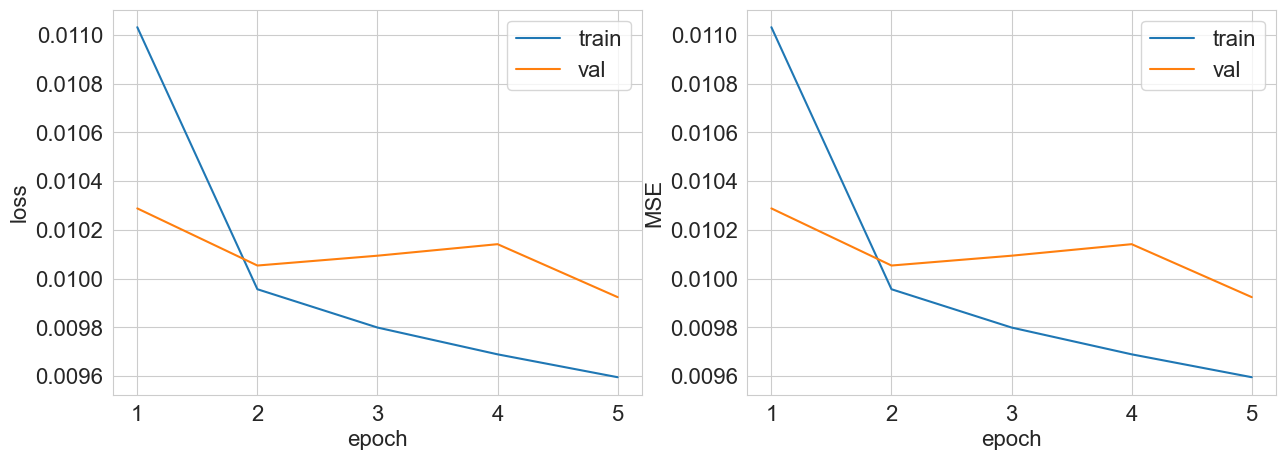

Validation MSE: 0.010


In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 5

list_metrics_Adam=[]

for i in range(5):
    
    np.random.seed(42 + i)
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.ReLU(),
        mm.Linear(128, 1),
        mm.Sigmoid()
    )
        
    optimizer = mm.Adam(model)
    
    criterion = mm.MSELoss()
    
    train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
    val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)
    
    metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())
    
    list_metrics_Adam.append(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                           num_epochs, verbose=True))
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

Заберем из массива данные с валидации после применения Adam

In [66]:
val_metrics_Adam = list(res[1] for res in list_metrics_Adam)

Посмотрим на графике какой из способов дает меньшие ошибки

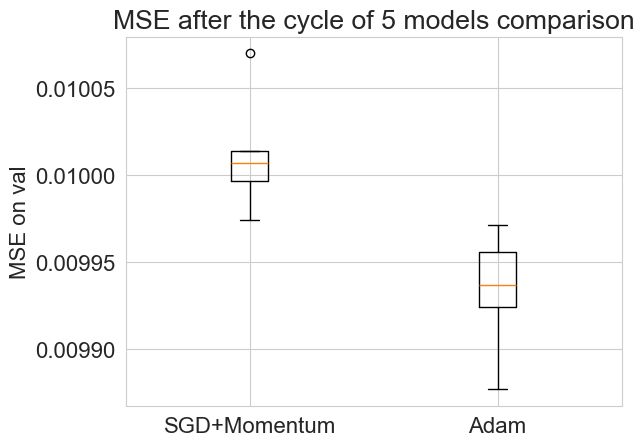

In [89]:
data = [val_metrics_SGD_M, val_metrics_Adam]

plt.boxplot(data, tick_labels=['SGD+Momentum', 'Adam'])
plt.ylabel('MSE on val')
plt.title('MSE after the cycle of 5 models comparison')
plt.grid(True)
plt.show()

Как мы можем заметить, Adam ведет себя лучше на валидации, потому что даже его максимальное значение по MSE на валидации ниже минимального по SGD + Momentum. Поэтому берем его

**Задание 2.2 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках.

Для начала рассмотрим более широкую модель

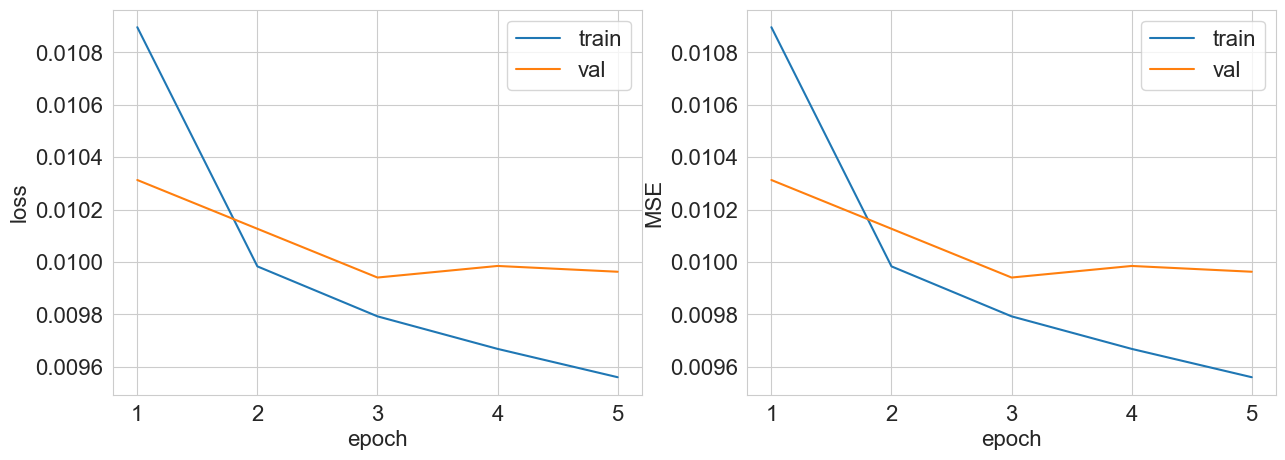

Validation MSE: 0.010


In [74]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZfrom sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 5

list_metrics_Adam_wide=[]

for i in range(5):
    
    np.random.seed(42 + i)
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 256),
        mm.ReLU(),
        mm.Linear(256, 1),
        mm.Sigmoid()
    )
        
    optimizer = mm.Adam(model)
    
    criterion = mm.MSELoss()
    
    train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
    val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)
    
    metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())
    
    list_metrics_Adam_wide.append(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                           num_epochs, verbose=True))
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

Теперь рассмотрим более глубокую модель

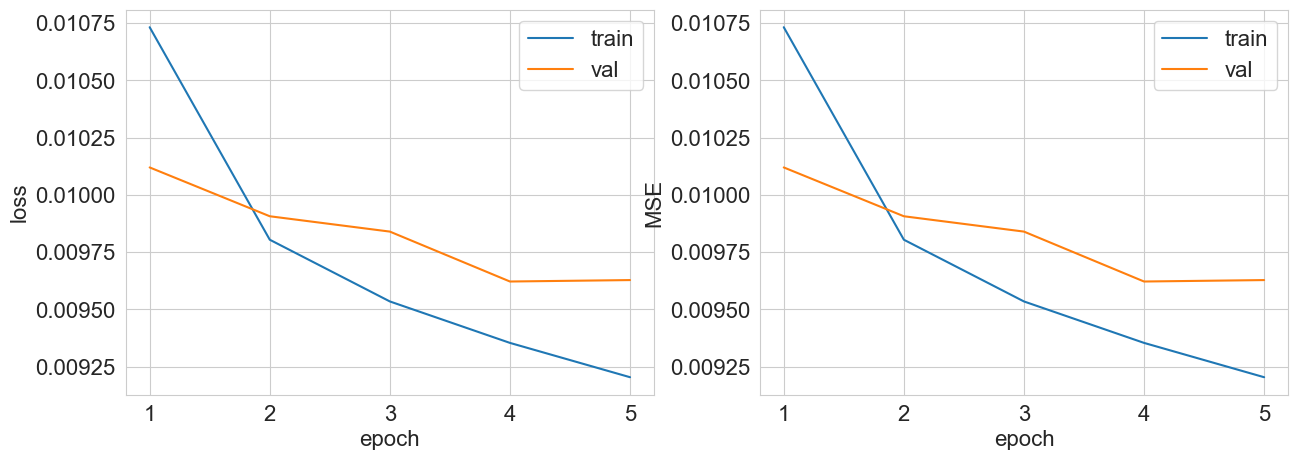

Validation MSE: 0.010


In [83]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZfrom sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 5

list_metrics_Adam_deep=[]

for i in range(5):
    
    np.random.seed(42 + i)
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.ReLU(),
        mm.Linear(128, 128),
        mm.ReLU(),
        mm.Linear(128, 1),
        mm.Sigmoid()
    )
        
    optimizer = mm.Adam(model)
    
    criterion = mm.MSELoss()
    
    train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
    val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)
    
    metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())
    
    list_metrics_Adam_deep.append(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                           num_epochs, verbose=True))
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

Теперь просто вытащим все данные, чтобы передать их в boxplot. Здесь у нас с валидации

In [84]:
val_metrics_Adam_wide = list(res[1] for res in list_metrics_Adam_wide)
val_metrics_Adam_deep = list(res[1] for res in list_metrics_Adam_deep)

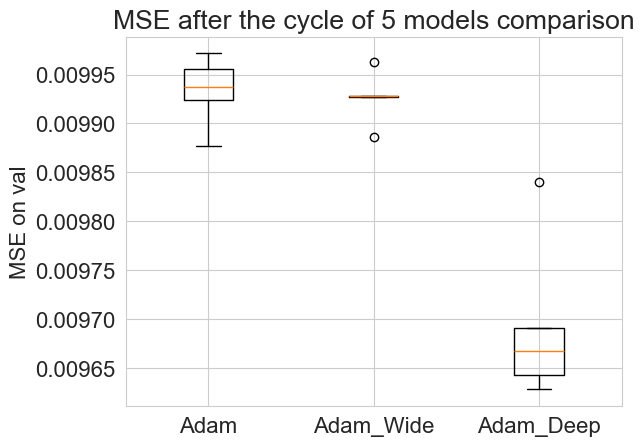

In [90]:
data = [val_metrics_Adam, val_metrics_Adam_wide, val_metrics_Adam_deep]

plt.boxplot(data, tick_labels=['Adam', 'Adam_Wide', 'Adam_Deep'])
plt.ylabel('MSE on val')
plt.title('MSE after the cycle of 5 models comparison')
plt.grid(True)
plt.show()

Здесь уже трейн

In [97]:
train_metrics_Adam = list(res[0] for res in list_metrics_Adam)
train_metrics_Adam_wide = list(res[0] for res in list_metrics_Adam_wide)
train_metrics_Adam_deep = list(res[0] for res in list_metrics_Adam_deep)

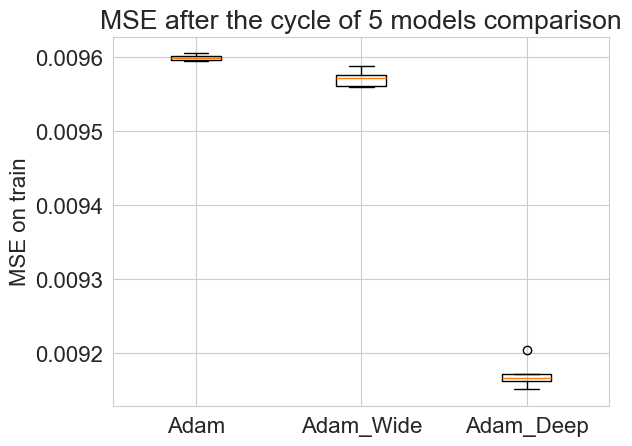

In [98]:
data = [train_metrics_Adam, train_metrics_Adam_wide, train_metrics_Adam_deep]

plt.boxplot(data, tick_labels=['Adam', 'Adam_Wide', 'Adam_Deep'])
plt.ylabel('MSE on train')
plt.title('MSE after the cycle of 5 models comparison')
plt.grid(True)
plt.show()

Как мы можем заметить, более глубокая модель является наиболее эффективной. Даже ее выбросы получаются не такими большими по сравнению с результатами других двух вариантов как на трейне, так и на валидации. 
Более широкая модель на трейне лучше даже по своему максимальному значению. На валидации медиана все-таки чуть ниже, чем у обычного Adam, зато 3 из 5 значений находятся очень близко друг к другу, что говорит о стабильности (или это просто нам повезло). 
Общий вывод в том, что усложнение модели приводит в целом к улучшениям, что на трейне, что на валидации

**Задание 2.3 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

Опишите результаты экспериментов. 

Хотел бы сразу объяснить, почему мы используем Dropout после ReLU, потому что в условии прям явно не прописывается это. Если бы мы сделали иначе, то Dropout по сути мог бы занулять отрицательные нейроны, которые и так были бы занулены ReLU, тем самым тратя свои мощности на и так нули. К тому же могло так произойти, что Dropout занулил много положительных нейронов. И в таком случае после ReLU в сети было бы слишком много нулей, что не позволяло бы сходиться градиентам. 

В свою очередь, при использовании Dropout после ReLU - сначала ReLU активирует нейроны, а потом Dropout работает с этими положительными нейронами, зануляя часть из них и не давая модели обучаться только за счет нейронов, которые постоянно активируются на наших входны данных или позволяют лучше по значениям определенных признаков предсказывать выход. Без них модель будет смотреть и на другие нейроны, обучаясь и по ним, что в итоге скорее всего на тестовых данных позволит лучше предсказывать.

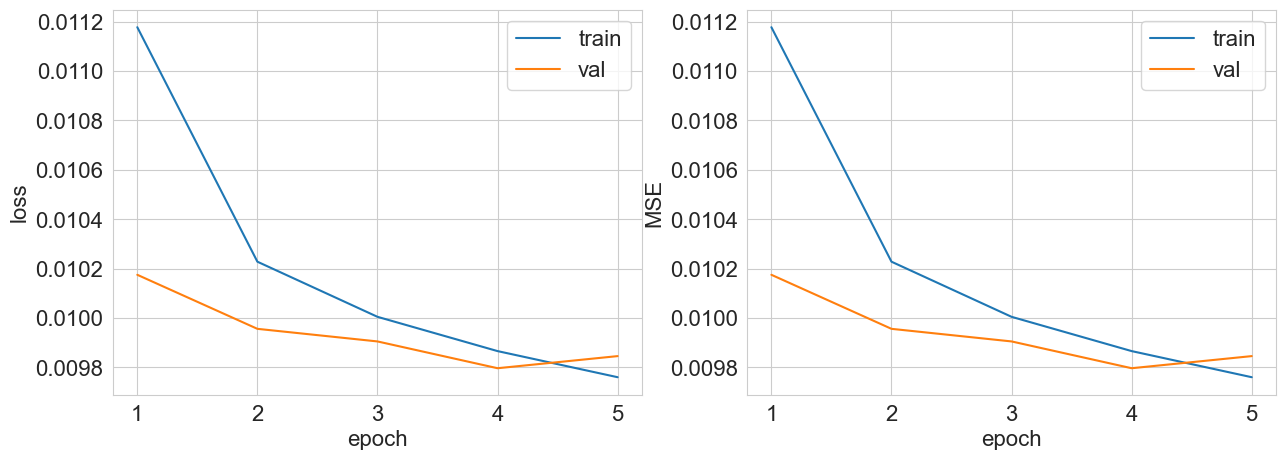

Validation MSE: 0.010


In [94]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZfrom sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 5

list_metrics_Adam_deep_drop=[]

for i in range(5):
    
    np.random.seed(42 + i)
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.ReLU(),
        mm.Dropout(p=0.2),       
        mm.Linear(128, 128),
        mm.ReLU(),
        mm.Dropout(p=0.2),
        mm.Linear(128, 1),
        mm.Sigmoid()
    )
        
    optimizer = mm.Adam(model)
    
    criterion = mm.MSELoss()
    
    train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
    val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)
    
    metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())
    
    list_metrics_Adam_deep_drop.append(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                           num_epochs, verbose=True))
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

BatchNorm используем до ReLU, потому что иначе ReLU смещало бы все стастики: матож был бы положительным всегда, а дисперсия была бы меньше, потому что у нас просто нет отрицательных значений.

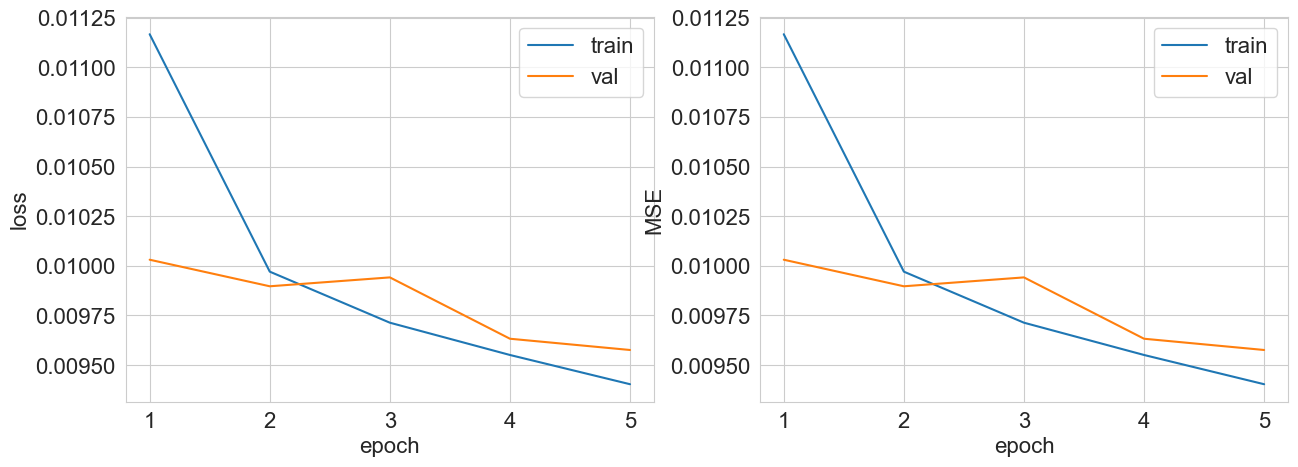

Validation MSE: 0.010


In [96]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZfrom sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 5

list_metrics_Adam_deep_norm=[]

for i in range(5):
    
    np.random.seed(42 + i)
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.BatchNormalization(128),
        mm.ReLU(),       
        mm.Linear(128, 128),
        mm.BatchNormalization(128),
        mm.ReLU(),
        mm.Linear(128, 1),
        mm.Sigmoid()
    )
        
    optimizer = mm.Adam(model)
    
    criterion = mm.MSELoss()
    
    train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
    val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)
    
    metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())
    
    list_metrics_Adam_deep_norm.append(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                           num_epochs, verbose=True))
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

Теперь посмотрим, что у нас получилось на графиках:

In [101]:
train_metrics_Adam_deep_drop = list(res[0] for res in list_metrics_Adam_deep_drop)
train_metrics_Adam_deep_norm = list(res[0] for res in list_metrics_Adam_deep_norm)

In [102]:
val_metrics_Adam_deep_drop = list(res[1] for res in list_metrics_Adam_deep_drop)
val_metrics_Adam_deep_norm = list(res[1] for res in list_metrics_Adam_deep_norm)

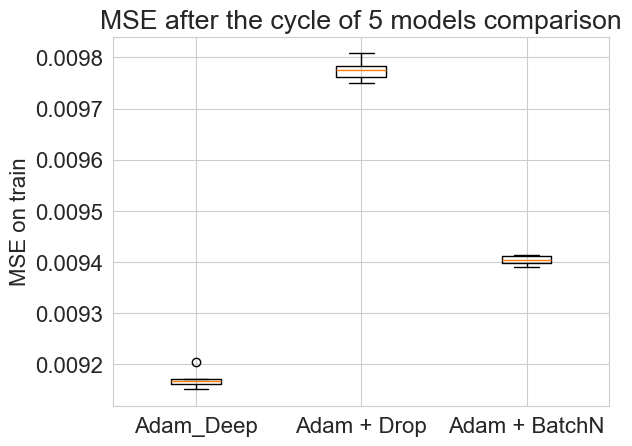

In [104]:
data = [train_metrics_Adam_deep, train_metrics_Adam_deep_drop, train_metrics_Adam_deep_norm]

plt.boxplot(data, tick_labels=['Adam_Deep', 'Adam + Drop', 'Adam + BatchN'])
plt.ylabel('MSE on train')
plt.title('MSE after the cycle of 5 models comparison')
plt.grid(True)
plt.show()

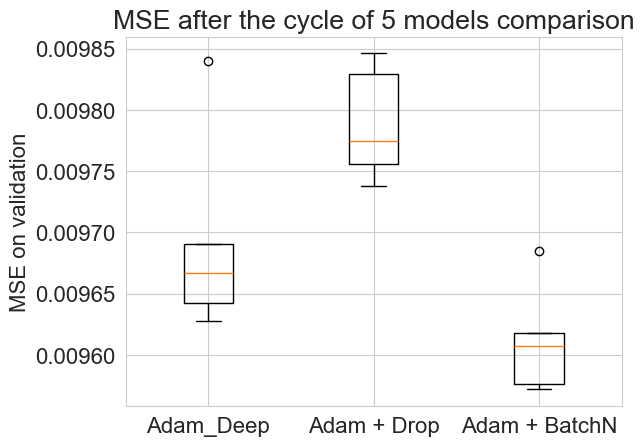

In [105]:
data = [val_metrics_Adam_deep, val_metrics_Adam_deep_drop, val_metrics_Adam_deep_norm]

plt.boxplot(data, tick_labels=['Adam_Deep', 'Adam + Drop', 'Adam + BatchN'])
plt.ylabel('MSE on validation')
plt.title('MSE after the cycle of 5 models comparison')
plt.grid(True)
plt.show()

Как мы видим, на тесте, если смотреть по самому маленькому MSE, то победил Adam_Deep. Но это и нормально, потому что модель на трейне регуляризовывалась через Dropout, а потому хоть она и больше ошибалась, зато не переобучалась. Тем не менее, на валидации тоже ошибка самая большая оказалась среди всех, поэтому скорее всего модель слишком регуляризовалась. Что касается батч норма - то при нем модель обучилась лучше всего. Все дело в том, что на трейне у нас постоянно подаются разные батчи со своими средними и дисперсиями, то есть со своими закономерностями из-за чего модель не может хорошо понять правильное направление. При этом, при валидации данные нормируются на фиксированные параметры running_mean и running_var, что позволяет модели лучше улавливать закономерности и при этом работать с данными, которые не имеют экстремальных значений, поскольку нормированны, в связи с чем сходимость будет лучше благодаря адекватным градиентам, а потому BatchNorm на валидации дает самые низкие значения MSE.

**Задание 2.4 (1.5 балла).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению MSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения), можете воспользоваться `verbose=False` в функции `train_and_validate`. Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости MSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

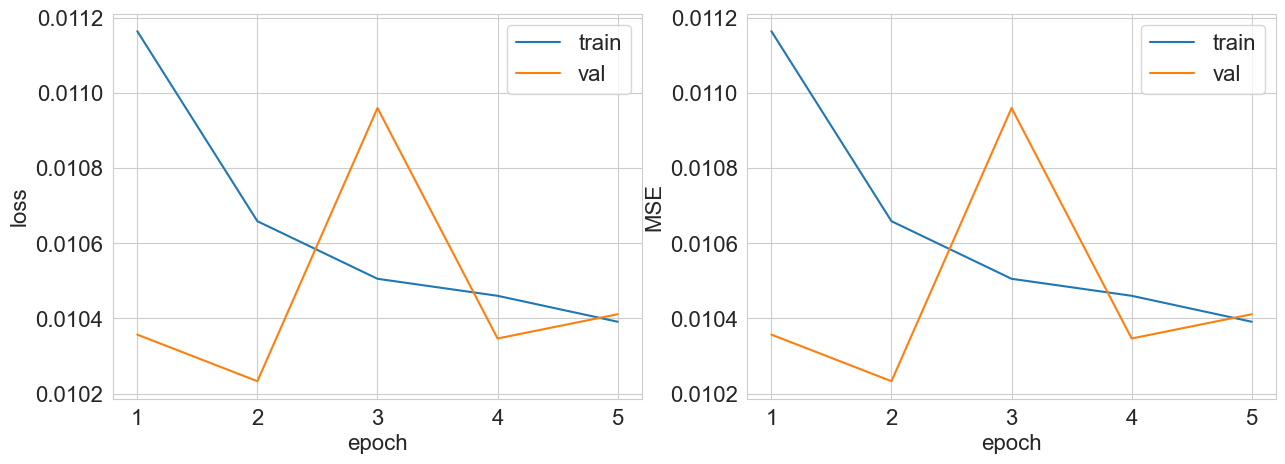

Validation MSE: 0.010


In [107]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
np.random.seed(42)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 5
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
results = {}

for lern in learning_rates:
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.BatchNormalization(128),
        mm.ReLU(),       
        mm.Linear(128, 128),
        mm.BatchNormalization(128),
        mm.ReLU(),
        mm.Linear(128, 1),
        mm.Sigmoid()
    )
        
    optimizer = mm.Adam(model, lr=lern)
    
    criterion = mm.MSELoss()
    
    train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
    val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)
    
    metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())
    
    results[lern]=(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                           num_epochs, verbose=True))
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

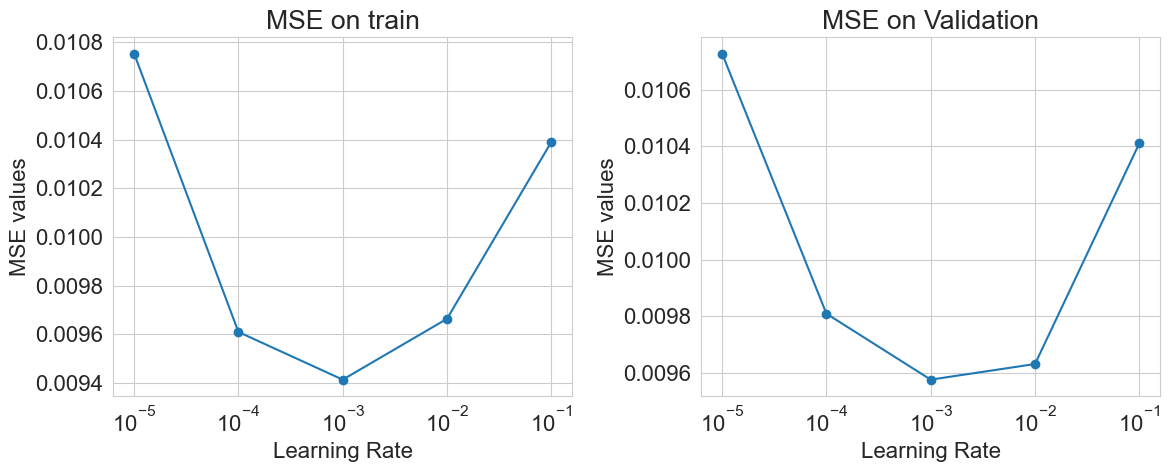

In [110]:
plt.figure(figsize=(12, 5))

lrs = np.array(list(results.keys()))
train_mses = np.array([mse_train for mse_train, _ in results.values()])
val_mses = np.array([mse_val for _, mse_val in results.values()])

plt.subplot(1, 2, 1)
plt.plot(lrs, train_mses, marker='o')
plt.title("MSE on train")
plt.xlabel("Learning Rate")
plt.ylabel("MSE values")
plt.xscale("log")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(lrs, val_mses, marker='o')
plt.title("MSE on Validation")
plt.xlabel("Learning Rate")
plt.ylabel("MSE values")
plt.xscale("log")
plt.grid(True)

plt.tight_layout()
plt.show()


Как мы можем видеть, наилучший lr оказался все равно 1e-3. Теперь подберем оптимальный вес с этим lr

In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
np.random.seed(42)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 4
weight_decays = [0.0] + list(np.logspace(-6, -3, num=6))
results_wd = {}

for wd in weight_decays:
    model = mm.Sequential(
        mm.Linear(X_train.shape[1], 128),
        mm.BatchNormalization(128),
        mm.ReLU(),       
        mm.Linear(128, 128),
        mm.BatchNormalization(128),
        mm.ReLU(),
        mm.Linear(128, 1),
        mm.Sigmoid()
    )
        
    optimizer = mm.Adam(model, lr=1e-3, weight_decay = wd)
    
    criterion = mm.MSELoss()
    
    train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
    val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)
    
    metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())
    
    results_wd[wd]=(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                           num_epochs, verbose=False))
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

In [ ]:
plt.figure(figsize=(12, 5))

wds = np.array(list(results_wd.keys()))
train_mses = np.array([mse_train for mse_train, _ in results_wd.values()])
val_mses = np.array([mse_val for _, mse_val in results_wd.values()])

plt.subplot(1, 2, 1)
plt.plot(wds, train_mses, marker='o')
plt.title("MSE on train")
plt.xlabel("Weight_Decay")
plt.ylabel("MSE values")
plt.xscale("log")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(wds, val_mses, marker='o')
plt.title("MSE on Validation")
plt.xlabel("Weight_Decay")
plt.ylabel("MSE values")
plt.xscale("log")
plt.grid(True)

plt.tight_layout()
plt.show()


Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.

**Задание 2.5 (0.5 балла).** Мы провели большое число экспериментов и подобрали оптимальную архитектуру и гиперпараметры. Пришло время обучить модель на полной обучающей выборке, померять качество на тестовой выборке и сравнить с бейзлайнами. Проделайте это. 

In [ ]:
np.random.seed(42)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

min_y = np.min(y_train)
max_y = np.max(y_train)

y_train_scaled = normalize(y_train, min_y, max_y)
y_val_scaled = normalize(y_val, min_y, max_y)

num_epochs = 5
        
optimizer = mm.Adam(model, lr=1e-3, weight_decay = optimal_wd)

criterion = mm.MSELoss()

train_loader = mm.DataLoader(X_train_scaled, y_train_scaled.reshape(-1, 1), batch_size=50, shuffle=True)
val_loader = mm.DataLoader(X_val_scaled, y_val_scaled.reshape(-1, 1), batch_size=50, shuffle=False)

metric = lambda x, y: mean_squared_error(y.flatten(), x.flatten())

results_wd[wd]=(train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=False))
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ